# 05 · Dynamics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/05_dynamics.ipynb)

> **ManipulaPy teaching course — notebook 5 of 11.** Running robot: Franka Panda.

Kinematics (notebooks 02–04) never mentioned mass or force. **Dynamics** puts them in. Everything in this notebook is one equation — the **manipulator equation** — relating joint torques $\tau$ to motion:

$$\tau = M(\theta)\,\ddot\theta \;+\; c(\theta,\dot\theta) \;+\; g(\theta) \;+\; J^{\top}(\theta)\,\mathcal{F}_{\text{tip}}.$$

- $M(\theta)$ — the **mass (inertia) matrix**
- $c(\theta,\dot\theta)$ — **Coriolis and centripetal** forces
- $g(\theta)$ — **gravity**
- $J^{\top}\mathcal{F}_{\text{tip}}$ — joint torques from an external end-effector wrench

It answers two questions. **Inverse dynamics**: what torques produce a desired motion (the engine of control, notebook 07)? **Forward dynamics**: what motion do given torques produce (the engine of simulation)? ManipulaPy's `ManipulatorDynamics` provides every term.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab. It is a **no-op when you run locally** from a clone of the repo.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS
np.set_printoptions(precision=4, suppress=True)

sm, dyn = load_panda()           # dyn is a ManipulatorDynamics
g = np.array([0.0, 0.0, -9.81])  # gravity in the base frame
Ftip = np.zeros(6)               # no external end-effector wrench
print("Panda dynamics loaded |", N_JOINTS, "joints")

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features
Panda dynamics loaded | 7 joints


pybullet build time: Jan 29 2025 23:16:28


## 1. The mass matrix $M(\theta)$

$M(\theta)$ maps joint accelerations to the inertial part of the torque, $\tau_{\text{inertia}}=M(\theta)\ddot\theta$. Two properties always hold: it is **symmetric**, and **positive-definite** — the kinetic energy $\tfrac12\dot\theta^{\top}M\dot\theta$ is positive for any non-zero motion. It also depends on the configuration: the arm's effective inertia changes as it folds and unfolds. The diagonal entries are the effective inertias seen by each joint; the off-diagonals are inertial **coupling** between joints.

In [3]:
M = dyn.mass_matrix(HOME)
print("M shape:", M.shape)
assert np.allclose(M, M.T)                          # symmetric
eigs = np.linalg.eigvalsh(M)
assert np.all(eigs > 0)                             # positive-definite
print("eigenvalues:", np.round(eigs, 3), "(all > 0)")
print("diagonal (effective joint inertias):", np.round(np.diag(M), 3))

M shape: (7, 7)
eigenvalues: [ 0.734  0.786  0.967  1.49   3.116 11.415 12.384] (all > 0)
diagonal (effective joint inertias): [7.509 7.092 5.744 4.539 3.    2.008 1.   ]


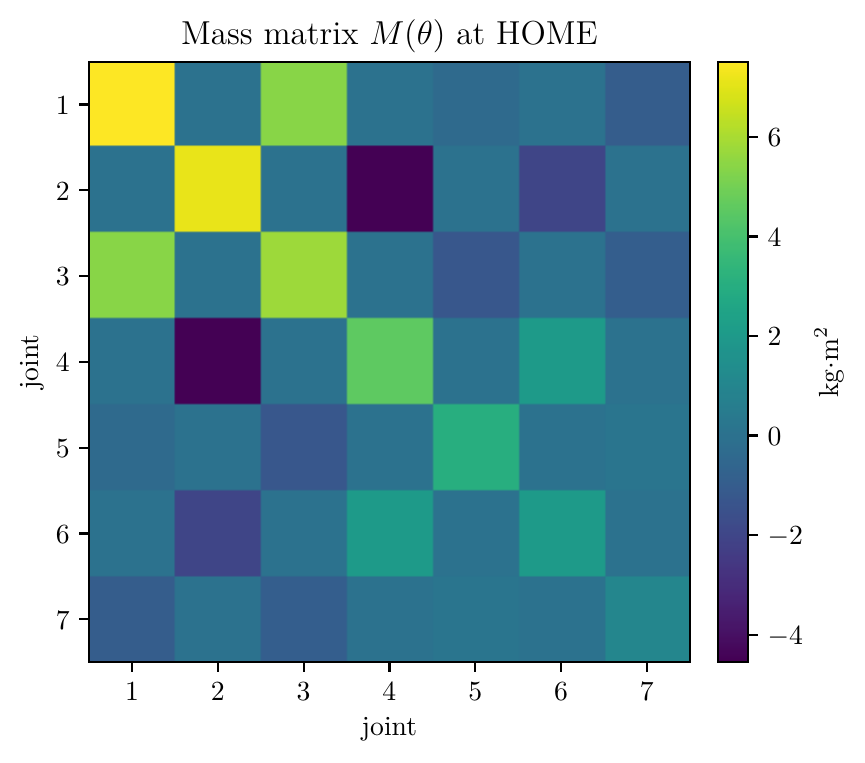

In [4]:
plt = setup_pgf()
fig, ax = plt.subplots(figsize=(4.6, 3.9))
im = ax.imshow(M, cmap='viridis')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='kg$\\cdot$m$^2$')
ax.set_xticks(range(N_JOINTS)); ax.set_yticks(range(N_JOINTS))
ax.set_xticklabels(range(1, N_JOINTS + 1)); ax.set_yticklabels(range(1, N_JOINTS + 1))
ax.set_xlabel('joint'); ax.set_ylabel('joint')
ax.set_title('Mass matrix $M(\\theta)$ at HOME')
embed_pgf_fig(fig, name="mass_matrix_heatmap")

## 2. Gravity $g(\theta)$

`gravity_forces` returns the torque each joint must exert **just to hold the arm still** against gravity (zero velocity, zero acceleration). At `HOME` the load falls almost entirely on the shoulder and elbow — the joints with the most arm hanging off them.

In [5]:
tau_g = dyn.gravity_forces(HOME, g)
print("gravity hold torques (N*m):", np.round(tau_g, 3))
print("heaviest joint:", int(np.argmax(np.abs(tau_g))) + 1)

gravity hold torques (N*m): [ -0.    -10.895   0.     12.383   0.      0.863  -0.   ]
heaviest joint: 4


### How the gravity load changes with configuration

Sweep joint 2 (the shoulder) through its range and watch the torque it must hold. The load peaks where that link is most **horizontal** — the longest gravity lever — and passes through lighter values as the arm tucks toward vertical, exactly like holding a weight at arm's length versus overhead.

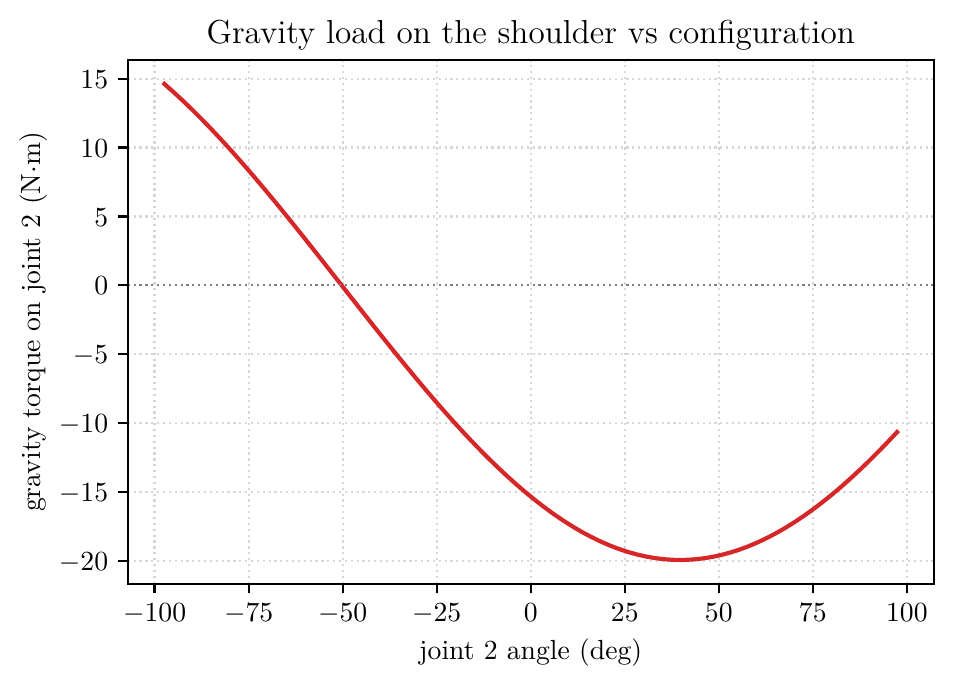

In [6]:
q2_range = np.linspace(-1.7, 1.7, 80)
tau2 = []
for a in q2_range:
    q = HOME.copy(); q[1] = a
    tau2.append(dyn.gravity_forces(q, g)[1])

plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.plot(np.degrees(q2_range), tau2, color='tab:red')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('joint 2 angle (deg)'); ax.set_ylabel('gravity torque on joint 2 (N$\\cdot$m)')
ax.set_title('Gravity load on the shoulder vs configuration')
ax.grid(True, ls=':', alpha=0.5)
embed_pgf_fig(fig, name="gravity_joint2_sweep")

## 3. Coriolis and centripetal forces $c(\theta,\dot\theta)$

When the joints are **moving**, the coupled links exert velocity-dependent fictitious forces on each other. `velocity_quadratic_forces` returns them. They are **quadratic** in the joint velocity (double the speed, quadruple the force) and vanish exactly when the arm is at rest.

In [7]:
dq = np.array([0.5, -0.3, 0.4, 0.2, -0.1, 0.3, 0.1])   # joint velocities
c = dyn.velocity_quadratic_forces(HOME, dq)
print("Coriolis/centripetal torques:", np.round(c, 4))

# Zero at rest; quadratic in speed.
assert np.allclose(dyn.velocity_quadratic_forces(HOME, np.zeros(N_JOINTS)), 0)
c2 = dyn.velocity_quadratic_forces(HOME, 2 * dq)
print("doubling speed scales the force by ~%.2fx (expect 4)" % (np.linalg.norm(c2) / np.linalg.norm(c)))
assert np.allclose(c2, 4 * c, rtol=1e-6)

Coriolis/centripetal torques: [-0.2064 -1.0352 -0.6824  0.4864  1.2307  0.3062 -0.0038]
doubling speed scales the force by ~4.00x (expect 4)


## 4. Inverse dynamics

Putting the terms together: given a motion $(\theta,\dot\theta,\ddot\theta)$, `inverse_dynamics` returns the torques that produce it. This is the whole manipulator equation evaluated in one call — and the basis of torque-level control (notebook 07). A useful sanity check: at rest with no acceleration, the required torque is exactly the gravity hold torque from Section 2.

In [8]:
ddq = np.array([0.2, 0.1, -0.3, 0.15, 0.05, -0.2, 0.1])   # joint accelerations
tau = dyn.inverse_dynamics(HOME, dq, ddq, g, Ftip)
print("required torques (N*m):", np.round(tau, 3))

# At rest and still, inverse dynamics reduces to gravity compensation.
tau_static = dyn.inverse_dynamics(HOME, np.zeros(N_JOINTS), np.zeros(N_JOINTS), g, Ftip)
assert np.allclose(tau_static, dyn.gravity_forces(HOME, g))
print("at rest, inverse dynamics == gravity_forces :", True)

required torques (N*m): [ -0.439 -11.496  -1.487  12.687   1.692   0.87    0.189]
at rest, inverse dynamics == gravity_forces : True


## 5. Forward dynamics

The reverse question — *what motion results from applied torques?* — solves the equation for the acceleration, $\ddot\theta = M^{-1}\big(\tau - c - g - J^{\top}\mathcal{F}_{\text{tip}}\big)$. `forward_dynamics` does exactly this. Because it inverts what inverse dynamics builds, feeding the torques from Section 4 straight back in must return the **same accelerations** — to machine precision.

In [9]:
ddq_recovered = dyn.forward_dynamics(HOME, dq, tau, g, Ftip)
print("recovered accelerations:", np.round(ddq_recovered, 4))
print("max error vs original:", np.max(np.abs(ddq_recovered - ddq)))
assert np.allclose(ddq_recovered, ddq, atol=1e-9)       # exact round trip

recovered accelerations: [ 0.2   0.1  -0.3   0.15  0.05 -0.2   0.1 ]
max error vs original: 4.163336342344337e-16


## 6. Simulating the arm under gravity

Integrating `forward_dynamics` over time **is** a physics simulation. We step the state with semi-implicit Euler: $\dot\theta \mathrel{+}= \ddot\theta\,dt$, then $\theta \mathrel{+}= \dot\theta\,dt$. Released from `HOME` with **zero torque**, the arm collapses under its own weight. Feed back the gravity torque $\tau=g(\theta)$ at every step — **gravity compensation** — and it hangs motionless, the simplest model-based controller there is.

In [10]:
def simulate(torque_fn, q0, T=0.6, dt=0.002):
    '''Integrate forward_dynamics from rest under torque_fn(q, dq). Returns (t, Q).'''
    q = np.array(q0, float); dq = np.zeros(N_JOINTS)
    ts, Q = [0.0], [q.copy()]
    for i in range(int(T / dt)):
        ddq = dyn.forward_dynamics(q, dq, torque_fn(q, dq), g, Ftip)
        dq = dq + ddq * dt          # semi-implicit Euler
        q = q + dq * dt
        ts.append((i + 1) * dt); Q.append(q.copy())
    return np.array(ts), np.array(Q)

t_fall, Q_fall = simulate(lambda q, dq: np.zeros(N_JOINTS), HOME)     # released, no torque
t_hold, Q_hold = simulate(lambda q, dq: dyn.gravity_forces(q, g), HOME)  # gravity compensation

print("free fall  : max joint drift %.1f deg" % np.degrees(np.abs(Q_fall[-1] - HOME).max()))
print("grav. comp.: max joint drift %.3f deg" % np.degrees(np.abs(Q_hold[-1] - HOME).max()))
assert np.degrees(np.abs(Q_fall[-1] - HOME).max()) > 10     # it really falls
assert np.degrees(np.abs(Q_hold[-1] - HOME).max()) < 0.1    # it really holds

free fall  : max joint drift 52.2 deg
grav. comp.: max joint drift 0.000 deg


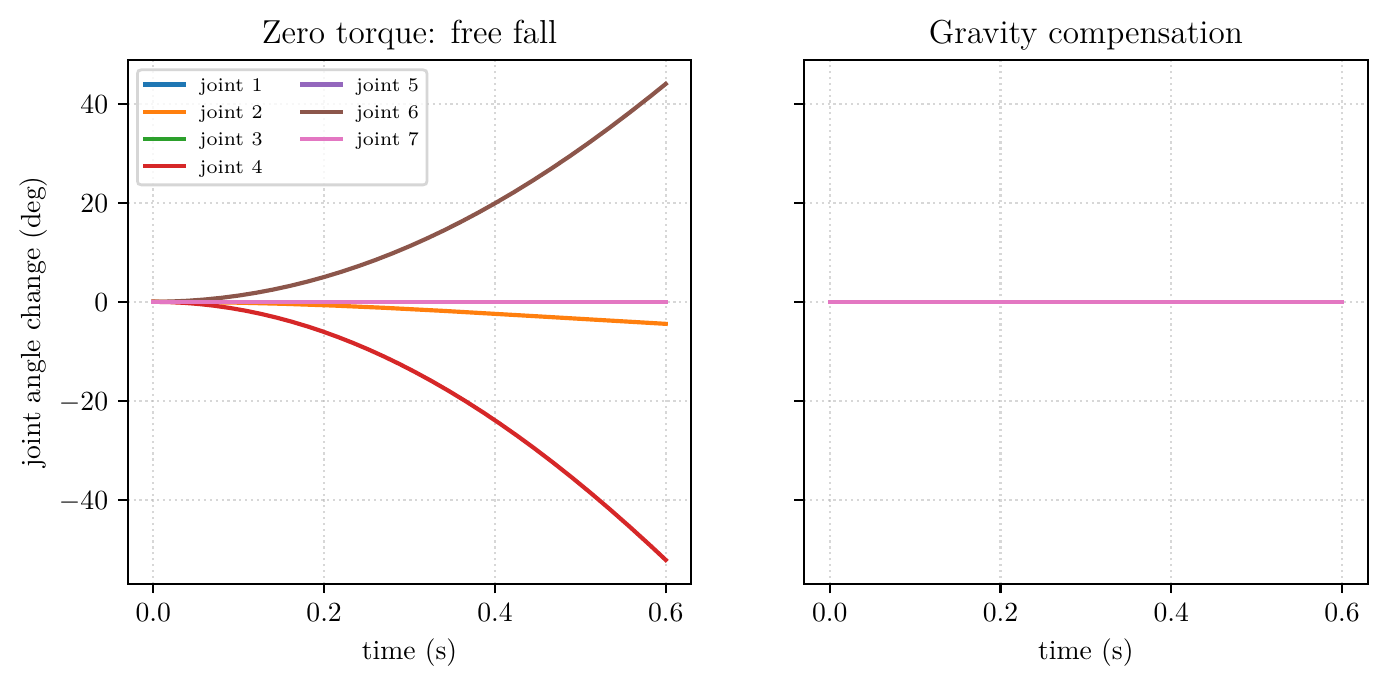

In [11]:
plt = setup_pgf()
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4), sharey=True)
for j in range(N_JOINTS):
    axes[0].plot(t_fall, np.degrees(Q_fall[:, j] - HOME[j]), label='joint %d' % (j + 1))
    axes[1].plot(t_hold, np.degrees(Q_hold[:, j] - HOME[j]))
axes[0].set_title('Zero torque: free fall'); axes[1].set_title('Gravity compensation')
for ax in axes:
    ax.set_xlabel('time (s)'); ax.grid(True, ls=':', alpha=0.5)
axes[0].set_ylabel('joint angle change (deg)')
axes[0].legend(fontsize=7, ncol=2)
embed_pgf_fig(fig, name="forward_dynamics_freefall")

## Smoke test

Asserts the key invariants of this notebook in one cell.

In [12]:
sm2, dyn2 = load_panda()
# Mass matrix is symmetric positive-definite.
M = dyn2.mass_matrix(HOME)
assert np.allclose(M, M.T) and np.all(np.linalg.eigvalsh(M) > 0)
# Coriolis vanishes at rest.
assert np.allclose(dyn2.velocity_quadratic_forces(HOME, np.zeros(N_JOINTS)), 0)
# At rest, inverse dynamics equals gravity compensation.
tau0 = dyn2.inverse_dynamics(HOME, np.zeros(N_JOINTS), np.zeros(N_JOINTS), g, Ftip)
assert np.allclose(tau0, dyn2.gravity_forces(HOME, g))
# Inverse dynamics and forward dynamics are inverses (round trip).
dq = np.array([0.5, -0.3, 0.4, 0.2, -0.1, 0.3, 0.1])
ddq = np.array([0.2, 0.1, -0.3, 0.15, 0.05, -0.2, 0.1])
tau = dyn2.inverse_dynamics(HOME, dq, ddq, g, Ftip)
assert np.allclose(dyn2.forward_dynamics(HOME, dq, tau, g, Ftip), ddq, atol=1e-9)
print("nb05 dynamics: smoke OK")

nb05 dynamics: smoke OK


## Try it

1. Read off the effective inertia of joint 1 from $M$ at `HOME`, then fold the arm (set joints 2 and 4 toward straight) and recompute. Does $M_{11}$ rise or fall, and why?
2. Apply a constant non-gravity torque to a single joint in `simulate` and watch how the whole arm responds — inertial coupling means one torque moves many joints.
3. Add an end-effector load: set `Ftip` to a downward force and recompute the inverse-dynamics torques. Which joints pick up the extra work?

*Next up — notebook 06: **singularities and manipulability** — where the Jacobian loses rank and the arm loses the ability to move in some direction.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapter 8, *Dynamics of Open Chains* (mass matrix, Coriolis, gravity, inverse/forward dynamics).
2. R. M. Murray, Z. Li, and S. S. Sastry, *A Mathematical Introduction to Robotic Manipulation*, CRC Press, 1994. — Lagrangian formulation of the manipulator equation.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
